# Market State Vector Example

This notebook reads local daily OHLC data from `data/spx_1d.csv`, takes log prices, builds the full online market state vector, extracts the compact core state vector, plots diagnostics, and runs the built-in evaluation.


In [14]:
import importlib
import random

import numpy as np
import pandas as pd

import cpd
import cpd.market_state_vector as msv

importlib.reload(msv)
importlib.reload(cpd)

from cpd import (
    load_data,
    build_market_state_vector,
    get_core_state_vector,
    evaluate_state_vector,
    plot_confirmed_high_low,
    plot_position_series,
    plot_price_state_background,
)


In [15]:
def random_month_window(index: pd.DatetimeIndex, months_count: int = 3) -> tuple[pd.Timestamp, pd.Timestamp]:
    months = index.to_period("M").unique()
    if len(months) == 0:
        raise ValueError("Cannot choose a random month from an empty index.")
    if len(months) <= months_count:
        return months[0].start_time, months[-1].end_time
    start_idx = random.randrange(0, len(months) - months_count + 1)
    window_months = months[start_idx : start_idx + months_count]
    return window_months[0].start_time, window_months[-1].end_time


In [16]:
raw_df = load_data(symbol="spx", interval="1d")
if (raw_df <= 0).any().any():
    raise ValueError("OHLC prices must be positive before taking logs.")

df = np.log(raw_df)

print(f"Loaded {len(df)} bars from data/spx_1d.csv")
df.head()


Loaded 4126 bars from data/spx_1d.csv


,Open,High,Low,Close
Date,,,,
2010-01-04,7.018008,7.033392,7.018008,7.032615
2010-01-05,7.032324,7.035823,7.029672,7.035726
2010-01-06,7.035013,7.038073,7.033462,7.036272
2010-01-07,7.035506,7.040939,7.031140,7.040265
2010-01-08,7.039240,7.043500,7.035462,7.043142


In [17]:
state_df = build_market_state_vector(
    data=df,
    detector_method="cusum",
    detector_q=1,
)


In [18]:
core_state_df = get_core_state_vector(state_df)
core_state_df.head(12)


,current_trend,current_phase,position,regime_slope,regime_volatility,dist_point3_pct
timestamp,,,,,,
2010-01-04,no_trend,no_phase,NaN,0.000000,0.000000,NaN
2010-01-05,no_trend,no_phase,NaN,0.003111,0.000000,NaN
2010-01-06,no_trend,no_phase,NaN,0.001828,0.001814,NaN
2010-01-07,no_trend,no_phase,NaN,0.002349,0.001791,NaN
2010-01-08,no_trend,no_phase,NaN,0.002559,0.001472,NaN
2010-01-11,no_trend,no_phase,NaN,0.002503,0.001335,NaN
2010-01-12,no_trend,no_phase,NaN,0.001205,0.004995,NaN
2010-01-13,no_trend,no_phase,NaN,0.001254,0.005433,NaN
2010-01-14,no_trend,no_phase,NaN,0.001356,0.005039,NaN


In [19]:
plot_start, plot_end = random_month_window(state_df.index, months_count=3)
print(f"Plotting diagnostic charts for {plot_start:%Y-%m} to {plot_end:%Y-%m}")


Plotting diagnostic charts for 2014-08 to 2014-10


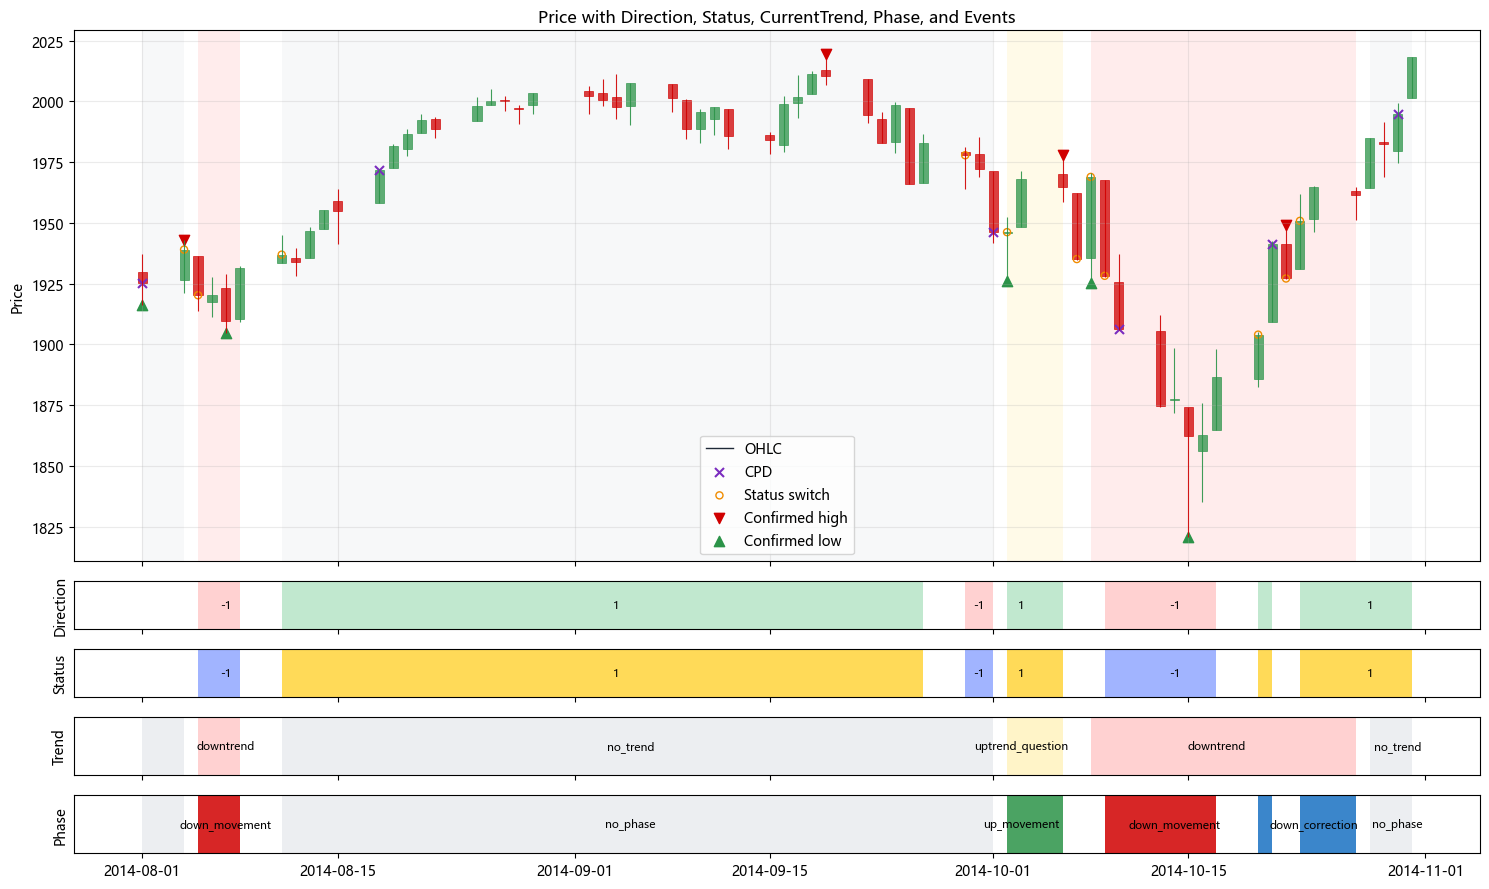

In [20]:
plot_price_state_background(
    state_df,
    price_is_log=True,
    start=plot_start,
    end=plot_end,
);


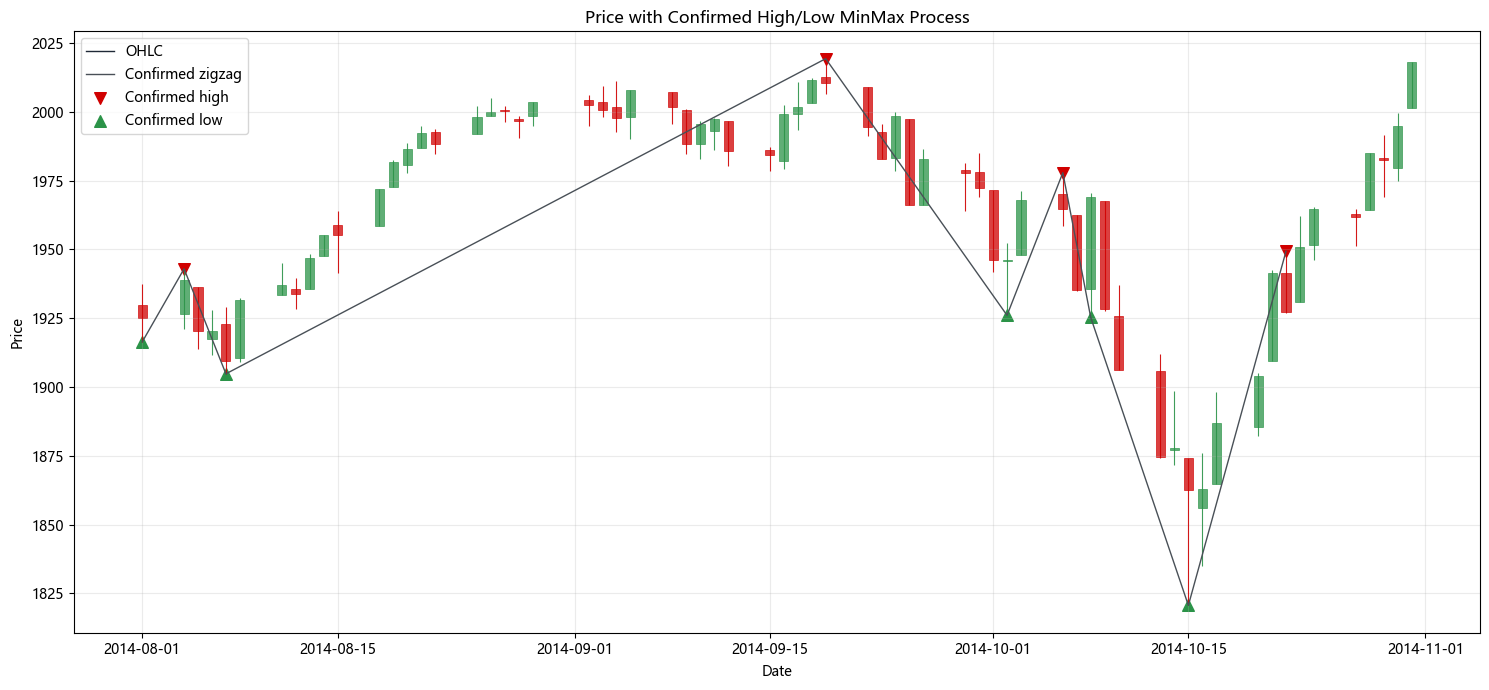

In [21]:
plot_confirmed_high_low(
    state_df,
    price_is_log=True,
    start=plot_start,
    end=plot_end,
);


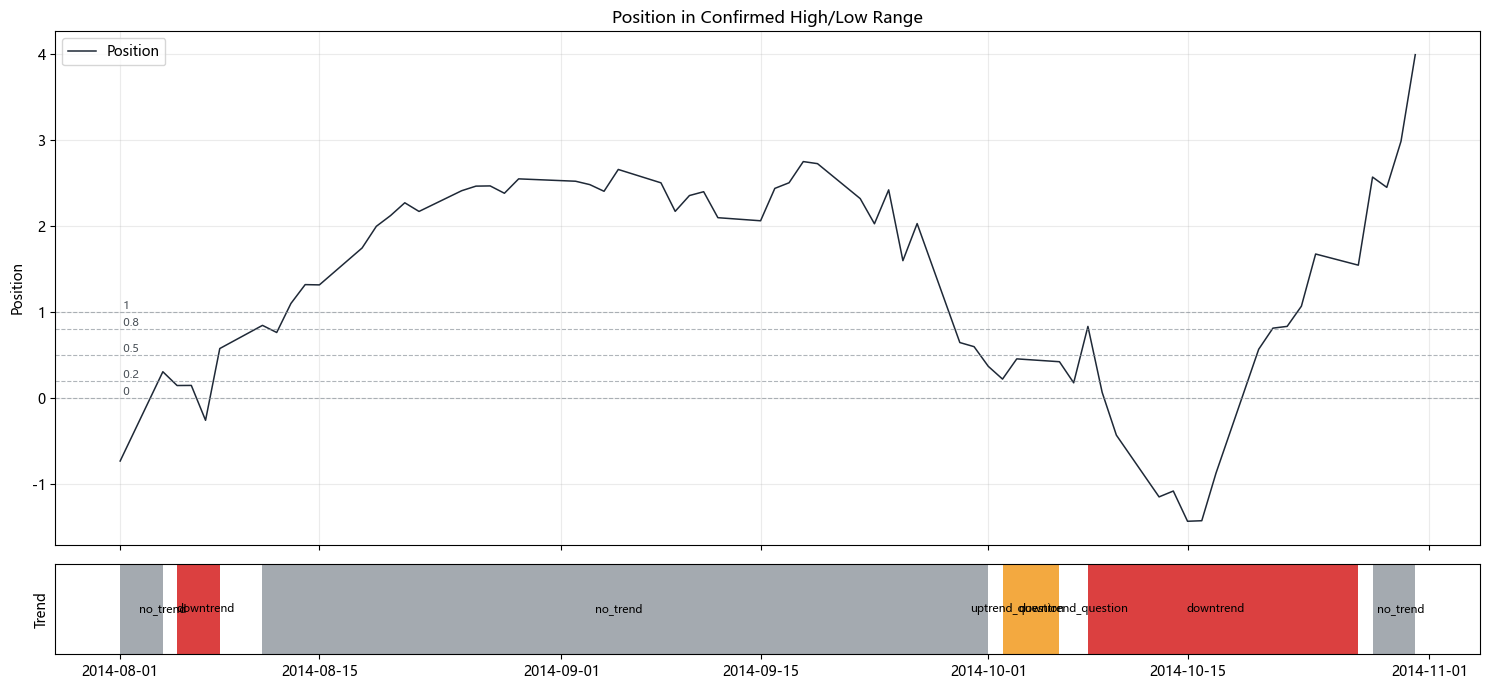

In [22]:
plot_position_series(
    state_df,
    start=plot_start,
    end=plot_end,
);


In [23]:
evaluation = evaluate_state_vector(
    state_df,
    price_is_log=True,
)

evaluation["state_duration_summary"]


,count,mean,median,min,max
current_trend,,,,,
downtrend,35,13.371429,9.0,1,73
downtrend_question,44,2.113636,2.0,1,11
no_trend,81,20.123457,17.0,1,93
uptrend,50,36.460000,21.0,1,303
uptrend_question,45,2.488889,1.0,1,9


In [24]:
evaluation["transition_matrix"]


current_trend,downtrend,downtrend_question,no_trend,uptrend,uptrend_question
current_trend,,,,,
downtrend,0.925214,0.000000,0.064103,0.000000,0.010684
downtrend_question,0.204301,0.526882,0.021505,0.129032,0.118280
no_trend,0.006748,0.015337,0.950307,0.009816,0.017791
uptrend,0.000000,0.003293,0.023600,0.973106,0.000000
uptrend_question,0.044643,0.116071,0.044643,0.196429,0.598214


In [25]:
evaluation["position_future_returns"][5]


,count,mean,std,median,min,max
position,,,,,,
"(-inf, 0.0]",481,0.002891,0.034047,0.005063,-0.198044,0.160395
"(0.0, 0.2]",183,0.004742,0.029469,0.006850,-0.080500,0.097697
"(0.2, 0.4]",280,0.005418,0.027312,0.007785,-0.117374,0.104081
"(0.4, 0.6]",379,0.002284,0.026248,0.006548,-0.122669,0.098984
"(0.6, 0.8]",470,0.001514,0.022993,0.004190,-0.122062,0.107173
"(0.8, 1.0]",552,0.001380,0.016450,0.002671,-0.088698,0.056203
"(1.0, inf]",1764,0.001989,0.016852,0.003727,-0.124364,0.066227


In [26]:
evaluation["trend_future_returns"][5]


,count,mean,std,median,min,max
current_trend,,,,,,
downtrend,468,0.006328,0.030632,0.008682,-0.122669,0.160395
downtrend_question,93,0.004110,0.027531,0.004948,-0.061497,0.073953
no_trend,1630,0.001278,0.024205,0.004271,-0.198044,0.107173
uptrend,1819,0.001826,0.017501,0.003128,-0.124364,0.070679
uptrend_question,111,0.006282,0.024185,0.009002,-0.060232,0.104081
